# **Student Performance Analysis**

### 1. Objective
### 2. Data Loading
### 3. Data Cleaning
### 4. Exploratory Data Analysis
### 5. Visualizations
### 6. Conclusion

## Objective
The objective of this project is to analyze student performance data using Python 

In [1]:
import zipfile
import pandas as pd

# Load dataset from zip
with zipfile.ZipFile(r"C:\Users\sanik\Downloads\student.zip") as z:
    with z.open("student-mat.csv") as f:
        df = pd.read_csv(f, sep=';')   # IMPORTANT

# Preview data
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


##  Data Cleaning

In [2]:
# Check Shape & Data Types
print(df.shape)
print(df.dtypes)

(395, 33)
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object


In [3]:
# Missing value check
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

No missing values found in dataset.

In [4]:
#Duplicate Check
df.duplicated().sum

<bound method Series.sum of 0      False
1      False
2      False
3      False
4      False
       ...  
390    False
391    False
392    False
393    False
394    False
Length: 395, dtype: bool>

No duplicate values found, ensuring data quality.

In [5]:
print("Final Shape:", df.shape)

Final Shape: (395, 33)


## Data Analysis

In [6]:
# Average Grade
avg_g3 = df['G3'].mean()
print("Average Final Grade (G3):", avg_g3)

Average Final Grade (G3): 10.415189873417722


The average final grade (G3) is approximately **10.42**, indicating that the overall student performance is moderate.

In [7]:
# Checking high pefoming student
above_15 = (df['G3'] > 15).sum()
print("Students scoring above 15:", above_15)

Students scoring above 15: 40



A total of **40 students** scored above 15 in the final grade (G3).

This indicates that only a small proportion of students achieved high scores, suggesting that high performance is relatively less common in the dataset.

In [8]:
# Correlation Analysis
df_subset = df[['studytime', 'G3']]
print(df_subset.head())

   studytime  G3
0          2   6
1          2   6
2          2  10
3          3  15
4          2  10


In [9]:
print(df_subset.describe())

        studytime          G3
count  395.000000  395.000000
mean     2.035443   10.415190
std      0.839240    4.581443
min      1.000000    0.000000
25%      1.000000    8.000000
50%      2.000000   11.000000
75%      2.000000   14.000000
max      4.000000   20.000000


In [10]:
print(df_subset.head(10))

   studytime  G3
0          2   6
1          2   6
2          2  10
3          3  15
4          2  10
5          2  15
6          2  11
7          2   6
8          2  19
9          2  15


In [11]:
correlation = df['studytime'].corr(df['G3'])
print("Correlation between Study Time and G3:", correlation)

Correlation between Study Time and G3: 0.0978196896531963


There is a weak positive relationship between study time and final grades, indicating that increased study time slightly improves performance.

In [12]:
#Gender Comparison
gender_performance = df.groupby('sex')['G3'].mean()
print(gender_performance)

sex
F     9.966346
M    10.914439
Name: G3, dtype: float64


This indicates that male students have slightly higher average performance compared to female students. However, the difference is not very large, suggesting that overall performance between genders is relatively similar.

## Visualizations

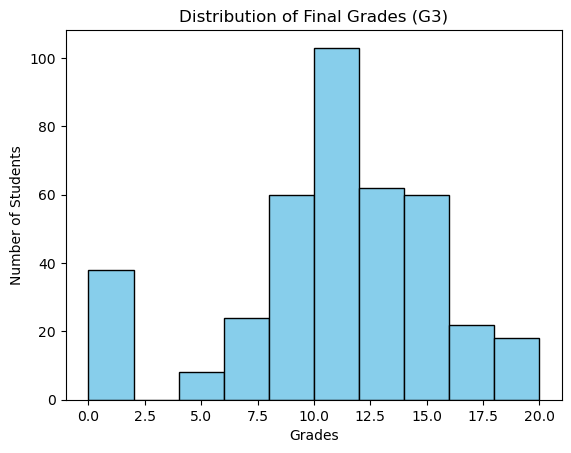

In [13]:
# Histogram of grades
import matplotlib.pyplot as plt
plt.hist(df['G3'], bins=10, color='skyblue', edgecolor='black')
plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Grades")
plt.ylabel("Number of Students")
plt.show()

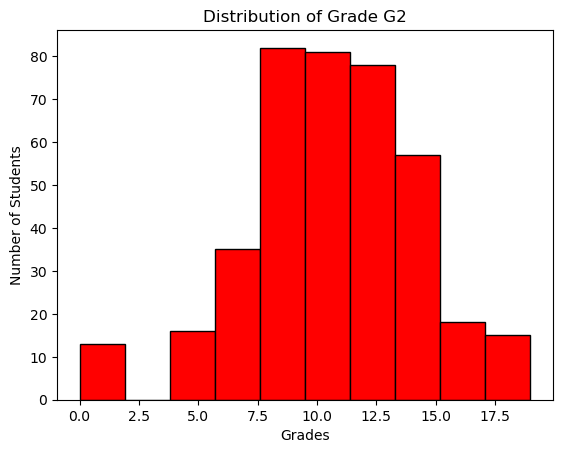

In [14]:
plt.hist(df['G2'], bins=10, color='red', edgecolor='black')
plt.title("Distribution of Grade G2")
plt.xlabel("Grades")
plt.ylabel("Number of Students")
plt.show()

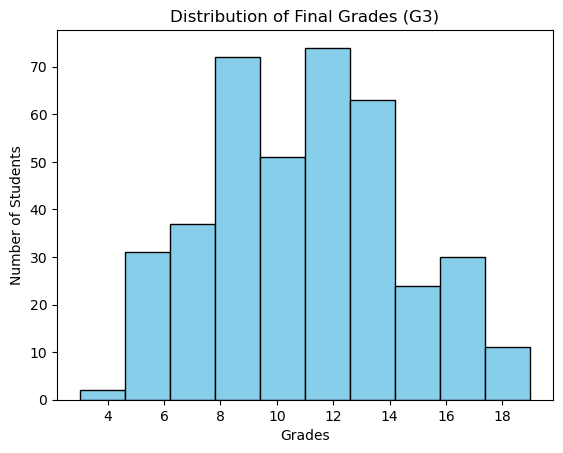

In [15]:
plt.hist(df['G1'], bins=10, color='skyblue', edgecolor='black')
plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Grades")
plt.ylabel("Number of Students")
plt.show()

Most students scored in the mid-range, indicating average performance.

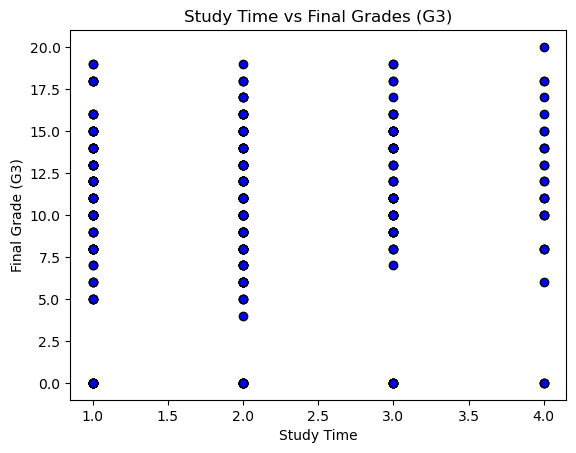

In [16]:
# Scatter plot
plt.scatter(df['studytime'], df['G3'], color='blue', edgecolor='black')
plt.title("Study Time vs Final Grades (G3)")
plt.xlabel("Study Time")
plt.ylabel("Final Grade (G3)")
plt.show()

There is a slight positive relationship between study time and performance.

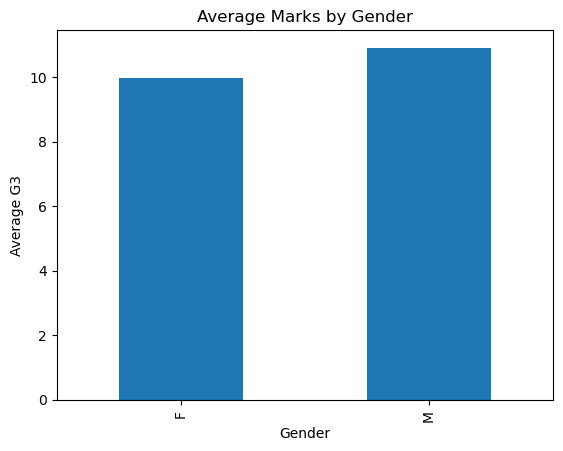

In [17]:
gender_avg = df.groupby('sex')['G3'].mean()
gender_avg.plot(kind='bar')
plt.title("Average Marks by Gender")
plt.xlabel("Gender")
plt.ylabel("Average G3")
plt.show()

The chart compares average marks between male and female students.

##  Conclusion

- The dataset was clean with no missing or duplicate values.
- Study time shows a weak positive impact on performance.
- Most students fall in the average score range.
- Gender comparison shows slight variation in performance.

This project demonstrates basic data analysis, visualization, and interpretation skills using Python.